# Beer Fermentation — PID Temperature Control

This notebook is built **directly on top of the disturbance notebook**.  
The only change is that `F_coolant_m3h` is no longer fixed — it is now computed by a PID controller.

---

| | Disturbance notebook | This notebook |
|---|---|---|
| **Coolant flow** | Fixed at 0.01 m³/hr | Set by PID controller |
| **Controlled variable** | — | Wort temperature |
| **Manipulated variable** | — | Coolant flow rate (m³/hr) |

### PID equation

$$F_{cool}(t) = K_r\,e(t) + \frac{K_r}{\tau_I}\int_0^t e\,dt + K_r\,\tau_D\,\frac{de}{dt}, \qquad e(t) = T_{set}(t) - T_{wort}(t)$$

The integral is implemented as an extra ODE state $I$ with $dI/dt = e(t)$.  
**Anti-windup:** the integral is frozen whenever $F_{cool}$ hits its physical limits.

> **Cooling-only constraint:** $F_{cool} \geq 0$ — the pump cannot run in reverse to heat the wort.  
> When fermentation slows and the wort naturally cools below $T_{set}$, the controller cannot correct this.


In [0]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

%matplotlib inline

# Compatibility shim: works on NumPy 1.x (Databricks) and 2.x
trapz = np.trapz if hasattr(np, 'trapz') else np.trapezoid

## Step 1 — PID parameters

These are the **only values you need to change** to explore different controller behaviours.

All physical constants below are identical to the disturbance notebook.

In [0]:
# ── PID controller parameters ──────────────────────────────────
#
#   Kr   : proportional gain
#   tauI : integral time (hr)  — smaller = faster offset removal
#   tauD : derivative time (hr) — set to 0 for PI only
K = 5.8
tau = 60

Kr   = -2    # proportional gain  (m3/hr per degC error)
tauI = 100   # integral time      (hr)
tauD =  0.05    # derivative time    (hr)

# ── Coolant flow limits ────────────────────────────────────────
F_min = 0.000   # pump off (cannot heat)
F_max = 0.11   # maximum pump capacity  (m3/hr)
T_max = 25 #C

# ── Disturbance ───────────────────────────────────────────────
disturbance_dT = 3.0   # degC step added to wort at 40% of run

print(f'PID: Kr={Kr}, tauI={tauI}, tauD={tauD}')
print(f'Flow limits: [{F_min}, {F_max}] m3/hr')

PID: Kr=-2, tauI=100, tauD=0.05
Flow limits: [0.0, 0.11] m3/hr


## Step 2 — Physical constants and setpoint

Identical to the disturbance notebook — nothing changed here.

In [0]:
# ── Simulation timing ─────────────────────────────────────────
duration      = 336
t_disturbance = 0.40 * duration   # 134.4 h

# ── Setpoint profile (same as disturbance notebook) ──────────
t_base   = np.linspace(0, duration, 1500)
Tset_arr = np.zeros(len(t_base))
for i, ti in enumerate(t_base):
    if   ti < 48:   Tset_arr[i] = 18
    elif ti < 300:  Tset_arr[i] = 19
    else:           Tset_arr[i] = 18

Tset_func  = interp1d(t_base, Tset_arr,                       fill_value='extrapolate')
dTset_func = interp1d(t_base, np.gradient(Tset_arr, t_base),  fill_value='extrapolate')

# ── Physical properties (identical to disturbance notebook) ───
ethanol_density             = 789
OG               = 1.048
yeast_pitch_rate = 0.75
yeast_density    = 40e-12       # g/cell
volume           = 1200         # L  (wort)
vessel_volume    = 1500         # L
vessel_volume_m3 = vessel_volume / 1000
temperature      = 18           # degC  (initial)
temperature_K    = temperature + 273.15

k_s  = 15.3;  k_e  = 6.31;   S_min = 13.1
g_x  = 0.0167; k_v  = 0.651;  k_co2 = 3.71
a_MB = 0.4;   b_MB = -1.1;   c_MB  = 0.025;  d_MB = -0.056

degP         = (-616.868) + (1111.14*OG) - (630.272*OG**2) + (135.997*OG**3)
wort_density_MB = OG * 1000
s_calc       = (degP/100) * wort_density_MB
yeast_req    = yeast_pitch_rate * (volume * 1000) * degP * 1e6
mass_yeast   = yeast_req * yeast_density
yeast_conc   = mass_yeast / volume

T_water_in   = 10               # degC  (coolant inlet temperature)
T_water_in_K = T_water_in + 273.15
water_density = (999.80 + 992.30) / 2
water_Cp      = 4.1789          # kJ/kg/K
wort_density  = (1048 + 1005) / 2
wort_Cp       = 4.0585          # kJ/kg/K

U      = 50                     # overall heat transfer coeff  (W/m2/K)
U_hr   = U * 3600               # J/m2/K/hr
delta_H = -587                  # kJ/kg  (heat of fermentation)
Area   = 0.3 * 14.137 / 2      # m2  (jacket heat transfer area)
V_wort_m3 = volume / 1000
Cooling_Jacket_Volume = vessel_volume_m3 * 0.05

print('Setup complete — all values identical to disturbance notebook.')
print(f'  Coolant inlet: {T_water_in} degC  |  U={U} W/m2/K  |  A={Area:.3f} m2')
print(f'  Jacket volume: {Cooling_Jacket_Volume:.4f} m3')

Setup complete — all values identical to disturbance notebook.
  Coolant inlet: 10 degC  |  U=50 W/m2/K  |  A=2.121 m2
  Jacket volume: 0.0750 m3


## Step 3 — ODE system

**8 state variables** — the disturbance notebook's 7 states plus one new PID integral state:

| Index | Variable | Description |
|---|---|---|
| 0 | `x` | Yeast concentration (g/L) |
| 1 | `s` | Residual sugar (mol/m³) |
| 2 | `e` | Ethanol (mol/m³) |
| 3 | `co2` | CO₂ (mol/m³) |
| 4 | `vdk` | Vicinal diketones (mol/m³) |
| 5 | `T` | Wort temperature (K) ← **controlled variable** |
| 6 | `Tc` | Jacket temperature (K) |
| 7 | `I` | PID integral state: dI/dt = e(t) |

The heat balances for wort and jacket are **word-for-word from the disturbance notebook**.  
The only addition is the PID block that replaces the fixed `F_coolant_m3h`.

In [0]:
def ODE_with_PID(t, state):

    x, s, e, co2, vdk, T, Tc, I = state

    # ── PID controller ────────────────────────────────────────
    # Error between setpoint and wort temperature
    error = Tset_func(t) - (T - 273.15)

    # PID output = coolant flow rate (m3/hr)
    # D term uses dTset/dt to avoid a spike when the setpoint steps
    #F_PID = Kr * error + (Kr / tauI) * I + Kr * tauD * dTset_func(t)
    temp = Kr * error + (Kr / tauI) * I + Kr * tauD * dTset_func(t)

    # Apply constraints to the valve (0 to F_max m^3/hr)
    F_coolant_m3h = F_min + temp 
    F_coolant_m3h = max(0.0, min(F_max, F_coolant_m3h))

 # Integrator (anti-windup: only integrate when valve is not saturated)
    if 0.0 < F_min + temp < F_max:
        dI_dt = error
    else:
        dI_dt = 0.0          # Anti-windup

    # ── Mass balances (unchanged from disturbance notebook) ───
    mu_max_T = a_MB * np.log(max(T - 273.15, 0.1)) + b_MB
    r_vdk_T  = c_MB * np.log(max(T - 273.15, 0.1)) + d_MB
    mu       = mu_max_T * (1 - S_min / s) if s >= S_min else 0.0

    dx_dt   = (mu * x) - (g_x * x)
    ds_dt   = -k_s * mu * x
    de_dt   =  k_e * mu * x
    dco2_dt =  k_co2 * mu * x
    dvdk_dt =  k_v * mu * x - r_vdk_T * vdk

    # ── Wort heat balance (unchanged from disturbance notebook) ─
    wort_temp_term1 = (ds_dt * delta_H
                       / (wort_density * wort_Cp))

    wort_temp_term2 = (Area * U_hr
                       / (V_wort_m3 * wort_density * wort_Cp * 1000)
                       * (T - Tc))

    dT_dt = wort_temp_term1 - wort_temp_term2

    # ── Jacket heat balance (unchanged from disturbance notebook) 
    # F_coolant_m3h is now the PID output instead of a fixed value
    water_temp_term1 = (F_coolant_m3h / Cooling_Jacket_Volume) * (T_water_in_K - Tc)
    water_temp_term2 = (Area * U_hr
                        / (Cooling_Jacket_Volume * water_density * water_Cp * 1000)
                        * (T - Tc))
    dTc_dt = water_temp_term1 + water_temp_term2

    return [dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, dT_dt, dTc_dt, dI_dt]

print('ODE defined.')

ODE defined.


## Step 4 — Run the simulation

Two segments as in the disturbance notebook: normal operation, then +3 °C injected at t = 134.4 h.

In [0]:
# ── Initial conditions ────────────────────────────────────────
# Same as disturbance notebook, plus I = 0 for the integral state
y0 = [yeast_conc, s_calc, 0.0, 0.0, 0.0,
      temperature_K,    # wort at 18 degC
      T_water_in_K,     # jacket at coolant inlet temp
      0.0]              # integral state = 0

# ── Time arrays ───────────────────────────────────────────────
n1     = int(2000 * t_disturbance / duration)
n2     = 2000 - n1
t_seg1 = np.linspace(0,             t_disturbance, n1)
t_seg2 = np.linspace(t_disturbance, duration,      n2)

# ── Segment 1: normal operation with PID ─────────────────────
sol1 = solve_ivp(ODE_with_PID, (0, t_disturbance),
                 y0, t_eval=t_seg1, method='BDF', max_step=0.1)
if not sol1.success:
    raise RuntimeError(f'Segment 1 failed: {sol1.message}')

# ── Apply disturbance: +3 degC to wort (state index 5) ───────
y_after = sol1.y[:, -1].copy()
T_before = y_after[5] - 273.15
y_after[5] += disturbance_dT

print(f'Wort temp just before disturbance : {T_before:.2f} degC')
print(f'Wort temp after +{disturbance_dT} degC step    : {y_after[5]-273.15:.2f} degC')

# ── Segment 2: PID rejects the disturbance ────────────────────
sol2 = solve_ivp(ODE_with_PID, (t_disturbance, duration),
                 y_after, t_eval=t_seg2, method='BDF', max_step=0.1)
if not sol2.success:
    raise RuntimeError(f'Segment 2 failed: {sol2.message}')

print('\nBoth segments solved successfully.')

# ── Stitch results ────────────────────────────────────────────
t_all = np.concatenate([sol1.t,    sol2.t[1:]])
y_all = np.concatenate([sol1.y,    sol2.y[:, 1:]], axis=1)

T_wort  = y_all[5] - 273.15   # wort temperature (degC)
T_jack  = y_all[6] - 273.15   # jacket temperature (degC)
I_state = y_all[7]             # integral state
Tset    = Tset_func(t_all)     # setpoint (degC)
error   = Tset - T_wort        # tracking error

# Reconstruct coolant flow history from PID equation
F_cool = np.clip(
    Kr * error + (Kr / tauI) * I_state + Kr * tauD * dTset_func(t_all),
    F_min, F_max
)

# ── Performance metrics ───────────────────────────────────────
i_d   = np.searchsorted(t_all, t_disturbance)
i_d1  = np.searchsorted(t_all, t_disturbance + 1)
i_d5  = np.searchsorted(t_all, t_disturbance + 5)
i_d10 = np.searchsorted(t_all, t_disturbance + 10)

peak_T = T_wort[i_d:].max()
t_peak = t_all[i_d + np.argmax(T_wort[i_d:])]
IAE    = trapz(np.abs(error[i_d:]), t_all[i_d:])

print(f'\n--- Post-disturbance performance ---')
print(f'  Peak wort temperature   : {peak_T:.2f} degC  at t = {t_peak:.1f} h')
print(f'  Max deviation from Tset : {(-error[i_d:]).max():.2f} degC')
print(f'  Temp 1 h after dist.    : {T_wort[i_d1]:.2f} degC  (setpoint {Tset[i_d1]:.1f} degC)')
print(f'  Temp 5 h after dist.    : {T_wort[i_d5]:.2f} degC')
print(f'  Temp 10 h after dist.   : {T_wort[i_d10]:.2f} degC')
print(f'  IAE (post-disturbance)  : {IAE:.1f} degC.h')

Wort temp just before disturbance : 18.78 degC
Wort temp after +3.0 degC step    : 21.78 degC

Both segments solved successfully.

--- Post-disturbance performance ---
  Peak wort temperature   : 21.73 degC  at t = 134.6 h
  Max deviation from Tset : 2.73 degC
  Temp 1 h after dist.    : 21.38 degC  (setpoint 19.0 degC)
  Temp 5 h after dist.    : 19.65 degC
  Temp 10 h after dist.   : 18.74 degC
  IAE (post-disturbance)  : 59.4 degC.h


## Step 5 — Plot results

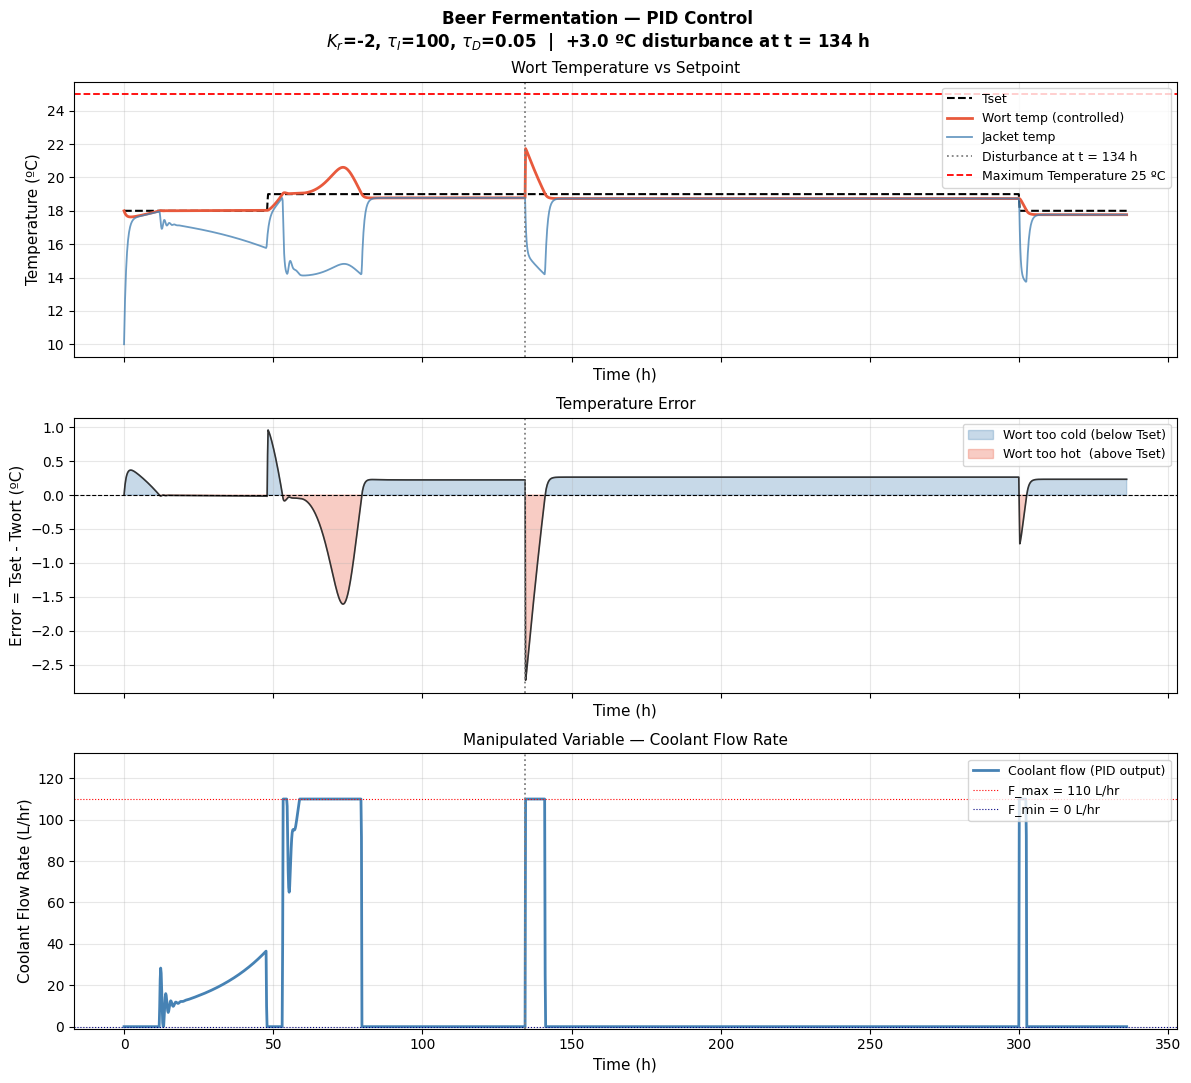

In [0]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.suptitle(
    f'Beer Fermentation — PID Control\n'
    f'$K_r$={Kr}, $\\tau_I$={tauI}, $\\tau_D$={tauD}  |  '
    f'+{disturbance_dT} ºC disturbance at t = {t_disturbance:.0f} h',
    fontsize=12, fontweight='bold'
)

# ── Panel 1: Wort and jacket temperature ─────────────────────
ax = axes[0]
ax.plot(t_all, Tset,   'k--', lw=1.5, label='Tset')
ax.plot(t_all, T_wort, color='#E8593C', lw=2.0, label='Wort temp (controlled)')
ax.plot(t_all, T_jack, color='steelblue', lw=1.3, alpha=0.8, label='Jacket temp')
ax.axvline(t_disturbance, color='grey', ls=':', lw=1.3,
           label=f'Disturbance at t = {t_disturbance:.0f} h')
ax.axhline(T_max, color='red', ls='--', lw=1.3,
           label=f'Maximum Temperature {T_max:.0f} ºC')
#ax.annotate(f'+{disturbance_dT:.0f} degC step',
#            xy=(t_disturbance, T_before + disturbance_dT),
#            xytext=(t_disturbance + 18, T_before + disturbance_dT + 0.8),
#            arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9)
ax.set_ylabel('Temperature (ºC)', fontsize=11)
ax.set_xlabel('Time (h)', fontsize=11)
ax.set_title('Wort Temperature vs Setpoint', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

# ── Panel 2: Temperature error ────────────────────────────────
ax = axes[1]
ax.fill_between(t_all, error, 0, where=(error > 0),
                color='steelblue', alpha=0.3, label='Wort too cold (below Tset)')
ax.fill_between(t_all, error, 0, where=(error < 0),
                color='#E8593C',  alpha=0.3, label='Wort too hot  (above Tset)')
ax.plot(t_all, error, color='#333', lw=1.2)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(t_disturbance, color='grey', ls=':', lw=1.3)
ax.set_ylabel('Error = Tset - Twort (ºC)', fontsize=11)
ax.set_xlabel('Time (h)', fontsize=11)
ax.set_title('Temperature Error', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

# ── Panel 3: Coolant flow rate (manipulated variable) ─────────
ax = axes[2]
ax.plot(t_all, F_cool * 1000, color='steelblue', lw=2.0,
        label='Coolant flow (PID output)')
ax.axhline(F_max * 1000, color='red',  lw=0.8, ls=':', label=f'F_max = {F_max*1000:.0f} L/hr')
ax.axhline(F_min * 1000, color='navy', lw=0.8, ls=':', label=f'F_min = {F_min*1000:.0f} L/hr')
ax.axvline(t_disturbance, color='grey', ls=':', lw=1.3)
ax.set_ylim(-1, F_max * 1000 * 1.2)
ax.set_ylabel('Coolant Flow Rate (L/hr)', fontsize=11)
ax.set_xlabel('Time (h)', fontsize=11)
ax.set_title('Manipulated Variable — Coolant Flow Rate', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/PID_Wort_Control.png', dpi=150, bbox_inches='tight')
plt.show()

In [0]:
# ─────────────────────────────────────────────────────────────
#  TEMPERATURE AT KEY MOMENTS
# ─────────────────────────────────────────────────────────────
idx_dist   = np.searchsorted(t_all, t_disturbance)
idx_dist_1 = np.searchsorted(t_all, t_disturbance + 1)
idx_dist_5 = np.searchsorted(t_all, t_disturbance + 5)
idx_dist10 = np.searchsorted(t_all, t_disturbance + 10)


print(f"Wort temperature just before disturbance  ({t_disturbance:.0f} h):   "
      f"{T_wort[idx_dist]:.2f} °C   (setpoint: {Tset[idx_dist]:.1f} °C)")
print(f"Wort temperature 1 h after disturbance    ({t_disturbance+1:.0f} h): "
      f"{T_wort[idx_dist_1]:.2f} °C")
print(f"Wort temperature 5 h after disturbance    ({t_disturbance+5:.0f} h): "
      f"{T_wort[idx_dist_5]:.2f} °C")
print(f"Peak wort temperature after disturbance:  "
      f"{T_wort[idx_dist:].max():.2f} °C  at t = "
      f"{t_all[idx_dist + np.argmax(T_wort[idx_dist:])]:.1f} h\n")



Wort temperature just before disturbance  (134 h):   18.78 °C   (setpoint: 19.0 °C)
Wort temperature 1 h after disturbance    (135 h): 21.38 °C
Wort temperature 5 h after disturbance    (139 h): 19.65 °C
Peak wort temperature after disturbance:  21.73 °C  at t = 134.6 h



In [0]:
# Stitch results (drop duplicate point at t_disturbance)
t_out  = np.concatenate([sol1.t,    sol2.t[1:]])
y_out  = np.concatenate([sol1.y,    sol2.y[:, 1:]], axis=1)

x_res  = y_out[0]
s_res  = y_out[1]
e_res  = y_out[2]
co2_res= y_out[3]
vdk_res= y_out[4]


T_C   = y_out[5] - 273.15      # wort temperature in °C
Tc_C   = y_out[6] - 273.15      # jacket temperature in °C

Tset_C = Tset_func(t_out)
error = Tset_C - T_C
abv_res   = (e_res / ethanol_density) * 100
ppb_res   = vdk_res * 1000

peak_T = T_wort[idx_dist:].max()
t_peak = t_all[idx_dist + np.argmax(T_wort[idx_dist:])]
IAE    = trapz(np.abs(error[idx_dist:]), t_all[idx_dist:]) #Integral Absolute Error
threshold = 50
window = 15


# Find index of peak VDK
i_peak = np.argmax(ppb_res)

# Look only after the peak
below_idx = np.where(ppb_res[i_peak:] < threshold)[0]

if len(below_idx) > 0:
    t_below_50 = t_all[i_peak + below_idx[0]]
    print(f"VDK drops below 50 ppb after peak at t = {t_below_50:.2f} hours")
else:
    print("VDK never drops below 50 ppb after the peak")

print(f'  IAE (post-disturbance)  : {IAE:.1f} degC.h')
i_window = np.searchsorted(t_all, t_disturbance + window)

# Compute overshoot = error at that exact time
overshoot = Tset[i_window] - T_wort[i_window]

print(f"Overshoot at t = {window} h after disturbance = {overshoot:.2f} °C")

# Extract the last values from the result arrays
final_abv = abv_res[-1]
final_ppb = ppb_res[-1]

print(f"--- Fermentation Summary ---")
print(f"Final ABV: {final_abv:.2f}%")
print(f"Final VDK: {final_ppb:.2f} ppb")

VDK drops below 50 ppb after peak at t = 320.70 hours
  IAE (post-disturbance)  : 59.4 degC.h
Overshoot at t = 15 h after disturbance = 0.26 °C
--- Fermentation Summary ---
Final ABV: 5.84%
Final VDK: 39.12 ppb


In [0]:

# 1. Define the disturbance time and your tolerance
t_disturb = t_disturbance
tolerance = 0.05  # How close to the setpoint (in degC) counts as "steady"

# 2. Convert your lists to numpy arrays (if they aren't already)
# Replace 't_list' and 'T_wort_list' with your actual variable names
time_arr = np.array(t_all) 
temp_arr = np.array(T_wort)
setpoint_arr = np.array(Tset)

# 3. Find the index where the disturbance starts
disturb_idx = np.where(time_arr >= t_disturb)[0][0]

# 4. Filter for data ONLY after the disturbance
post_disturb_temps = temp_arr[disturb_idx:]
post_disturb_times = time_arr[disturb_idx:]
post_disturb_setpoints = setpoint_arr[disturb_idx:]

# 5. Find the first index where the temp is within the tolerance of the setpoint
# We use np.abs to check if the difference is small
is_steady = np.abs(post_disturb_temps - post_disturb_setpoints) <= tolerance

# Find the first 'True' in the is_steady array
if np.any(is_steady):
    recovery_idx = np.where(is_steady)[0][0]
    t_steady = post_disturb_times[recovery_idx]
    
    duration = t_steady - t_disturb
    print(f"Recovery Duration: {duration:.2f} hours")
else:
    print("Temperature did not reach steady state within the simulation time.")

Recovery Duration: 6.73 hours


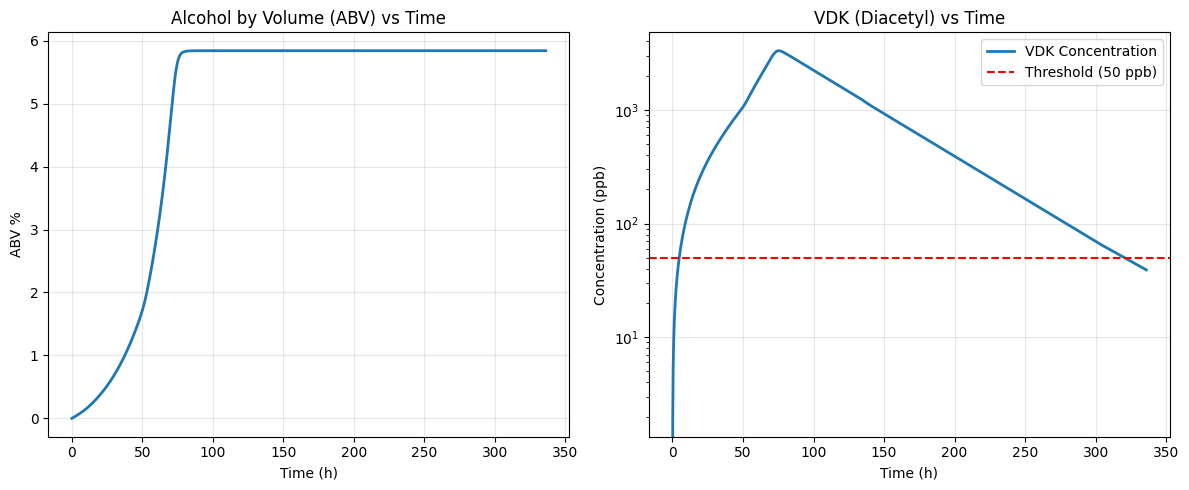

In [0]:

plt.figure(figsize=(12, 5))

# Subplot 1: ABV (Ethanol) accumulation
plt.subplot(1, 2, 1)
plt.plot(t_out, abv_res, linewidth=2)
plt.title('Alcohol by Volume (ABV) vs Time')
plt.xlabel('Time (h)')
plt.ylabel('ABV %')
plt.grid(True, alpha=0.3)

# Subplot 2: VDK/PPB Reduction
plt.subplot(1, 2, 2)
plt.plot(t_out, ppb_res, linewidth=2, label='VDK Concentration')
# Add a horizontal line for the flavor threshold
plt.axhline(y=50, color='red', linestyle='--', label='Threshold (50 ppb)')

plt.title('VDK (Diacetyl) vs Time')
plt.xlabel('Time (h)')
plt.ylabel('Concentration (ppb)')
plt.yscale('log') # VDK often drops exponentially, log scale helps visibility
plt.legend()
plt.grid(False, ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Parameter sweep

Change `sweep_param` and `sweep_values` to compare how each PID parameter affects disturbance rejection.

**Suggested experiments:**
- `sweep_param = 'Kr'`   with `sweep_values = [-0.5, -2.0, -5.0, -10.0]`
- `sweep_param = 'tauI'` with `sweep_values = [2, 5, 10, 30]`
- `sweep_param = 'tauD'` with `sweep_values = [0, 0.5, 1.0, 2.0]`

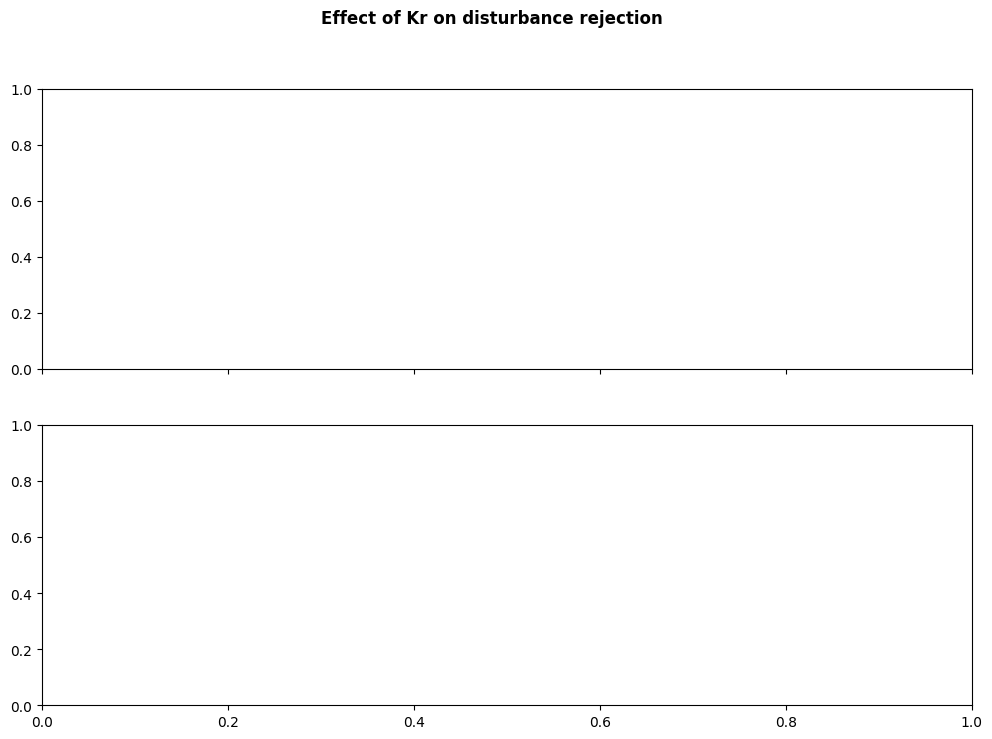

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-8010404138816078>, line 38
     35 s1 = solve_ivp(ode_sweep, (0, t_disturbance), y0,
     36                t_eval=t_seg1, method='BDF', max_step=0.1)
     37 yd = s1.y[:, -1].copy();  yd[5] += disturbance_dT
---> 38 s2 = solve_ivp(ode_sweep, (t_disturbance, duration), yd,
     39                t_eval=t_seg2, method='BDF', max_step=0.1)
     41 t_sw  = np.concatenate([s1.t,    s2.t[1:]])
     42 T_sw  = np.concatenate([s1.y[5], s2.y[5,1:]]) - 273.15

File /databricks/python/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:551, in solve_ivp(fun, t_span, y0, method, t_eval, dense_output, events, vectorized, args, **options)
    548     raise ValueError("`t_eval` must be 1-dimensional.")
    550 if np.any(t_eval < min(t0, tf)) or np.any(t_eval > max(t0, tf)):
--> 551     raise ValueError("Values in `t_eval` are not w

In [0]:
# ── Change these two lines ────────────────────────────────────
sweep_param  = 'Kr'
sweep_values = [-0.5, -2.0, -5.0, -10.0, -20.0]
#sweep_param = 'tauI'
#sweep_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0,100.0]
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f'Effect of {sweep_param} on disturbance rejection',
             fontsize=12, fontweight='bold')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(sweep_values)))

for val, col in zip(sweep_values, colors):

    _Kr   = val  if sweep_param == 'Kr'   else Kr
    _tauI = val  if sweep_param == 'tauI' else tauI
    _tauD = val  if sweep_param == 'tauD' else tauD

    def ode_sweep(t, state, k=_Kr, ti=_tauI, td=_tauD):
        x, s, e, co2, vdk, T, Tc, I = state
        err  = Tset_func(t) - (T - 273.15)
        F_p  = k * err + (k / ti) * I + k * td * dTset_func(t)
        F_c  = float(np.clip(F_p, F_min, F_max))
        dI   = 0.0 if (F_p <= F_min or F_p >= F_max) else err
        mu_max = a_MB * np.log(max(T-273.15, 0.1)) + b_MB
        r_vdk  = c_MB * np.log(max(T-273.15, 0.1)) + d_MB
        mu   = mu_max * (1 - S_min/s) if s >= S_min else 0.0
        ds   = -k_s * mu * x
        dT   = (ds*delta_H/(wort_density*wort_Cp)) \
               - (Area*U_hr/(V_wort_m3*wort_density*wort_Cp*1000)) * (T - Tc)
        dTc  = (F_c/Cooling_Jacket_Volume)*(T_water_in_K - Tc) \
               + (Area*U_hr/(Cooling_Jacket_Volume*water_density*water_Cp*1000)) * (T - Tc)
        return [mu*x-g_x*x, ds, k_e*mu*x, k_co2*mu*x, k_v*mu*x-r_vdk*vdk, dT, dTc, dI]

    s1 = solve_ivp(ode_sweep, (0, t_disturbance), y0,
                   t_eval=t_seg1, method='BDF', max_step=0.1)
    yd = s1.y[:, -1].copy();  yd[5] += disturbance_dT
    s2 = solve_ivp(ode_sweep, (t_disturbance, duration), yd,
                   t_eval=t_seg2, method='BDF', max_step=0.1)

    t_sw  = np.concatenate([s1.t,    s2.t[1:]])
    T_sw  = np.concatenate([s1.y[5], s2.y[5,1:]]) - 273.15
    I_sw  = np.concatenate([s1.y[7], s2.y[7,1:]])
    err_sw = Tset_func(t_sw) - T_sw
    F_sw  = np.clip(_Kr*err_sw + (_Kr/_tauI)*I_sw
                    + _Kr*_tauD*dTset_func(t_sw), F_min, F_max)

    axes[0].plot(t_sw, T_sw,      color=col, lw=1.8, label=f'{sweep_param} = {val}')
    axes[1].plot(t_sw, F_sw*1000, color=col, lw=1.8)

axes[0].plot(t_all, Tset, 'k--', lw=1.5, label='Tset')
axes[0].axvline(t_disturbance, color='grey', ls=':', lw=1.2)
axes[0].set_ylabel('Wort Temperature (degC)', fontsize=11)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(alpha=0.3)

axes[1].axhline(F_max*1000, color='red',  lw=0.8, ls=':', label='F_max')
axes[1].axhline(F_min*1000, color='navy', lw=0.8, ls=':', label='F_min')
axes[1].axvline(t_disturbance, color='grey', ls=':', lw=1.2)
axes[1].set_ylabel('Coolant Flow Rate (L/hr)', fontsize=11)
axes[1].set_xlabel('Time (h)', fontsize=11)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/PID_Wort_Sweep.png', dpi=150, bbox_inches='tight')
plt.show()